# 📊 Structural Invariants & Spectral Metrics Validation

This notebook validates advanced structural invariants, phase-space contractions, and spectral breakdowns across non-uniform network topologies using `kuramoto.metrics.analytics_engine`.

## 📋 Agenda
1. **Setup & Network Configuration:** Initialize a non-uniform 100-oscillator network using `build_adjacency`.
2. **Simulation:** Run Kuramoto dynamics and map states to the Clifford geometric rotor representation.
3. **Comprehensive Diagnostics:** Compute Hamiltonian invariants, phase-space contraction rate ($\Lambda(t)$), and PSD spectral decomposition.
4. **4-Panel Diagnostic Visualization:** Generate multi-panel diagnostic plots tracking energy drift, contraction rate, PSD peaks, and power distribution breakdown.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.integrate import solve_ivp

from kuramoto.analysis.graphs import build_adjacency
from kuramoto.metrics.analytics_engine import compute_comprehensive_diagnostics

# Visualization styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 10)
plt.rcParams["font.size"] = 11

print("🚀 Environment ready for structural metrics validation!")

🚀 Environment ready for structural metrics validation!


## 1️⃣ Network Initialization & Simulation
Initialize a non-uniform 100-oscillator network topology (Watts-Strogatz small-world graph) and run the dynamics.

In [6]:
# Simulation configuration
n_oscillators = 100
K = 1.8
t_max = 20.0
n_timesteps = 1000
times = np.linspace(0.0, t_max, n_timesteps)
seed = 27
rng = np.random.default_rng(seed)

# 1. Initialize a non-uniform network topology
G = nx.watts_strogatz_graph(n_oscillators, k=8, p=0.25, seed=seed)
raw_adj = nx.to_numpy_array(G)
adj = build_adjacency(n_oscillators, raw_adj)

# 2. Natural frequencies and initial phases
omega = rng.normal(loc=0.0, scale=1.0, size=n_oscillators)
theta0 = rng.uniform(0.0, 2.0 * np.pi, size=n_oscillators)

# 3. Simulate Kuramoto ODE on non-uniform network
def kuramoto_ode(t, theta):
    diff = theta[:, None] - theta[None, :]
    coupling = (K / n_oscillators) * np.sum(adj * np.sin(-diff), axis=1)
    return omega + coupling

sol = solve_ivp(
    kuramoto_ode,
    (0.0, t_max),
    theta0,
    t_eval=times,
    method="RK45",
    rtol=1e-7,
    atol=1e-9,
)
theta_history = sol.y.T  # Shape: (T, N)

# 4. Map phases to Geometric Algebra rotor representation: R(t) = exp(-I theta / 2) = cos(theta/2) - 1j * sin(theta/2)
rotor_history = np.cos(theta_history / 2.0) - 1j * np.sin(theta_history / 2.0)

print(f"✅ Simulation completed: {rotor_history.shape} steps for {n_oscillators} oscillators.")

✅ Simulation completed: (1000, 100) steps for 100 oscillators.


## 2️⃣ Compute Structural & Spectral Diagnostics
Invoke `compute_comprehensive_diagnostics` to calculate Hamiltonian invariants, volume contraction rates, and spectral decomposition.

In [7]:
metrics = compute_comprehensive_diagnostics(
    rotor_history=rotor_history,
    times=times,
    K=K,
    adjacency_in=adj,
)

print(f"📊 Total Hamiltonian Energy Drift: {metrics.total_energy_drift:.6e}")
print(f"📈 Primary Spectral Frequency: {metrics.spectral_frequencies[np.argmax(metrics.spectral_psd_mean)]:.4f} Hz")
print("🔬 Energy Decomposition Breakdown:")
for k, v in metrics.energy_decomposition.items():
    print(f"   - {k.capitalize()}: {v * 100.0:.2f}%")

📊 Total Hamiltonian Energy Drift: 6.382342e-02
📈 Primary Spectral Frequency: 0.1951 Hz
🔬 Energy Decomposition Breakdown:
   - Fundamental: 55.49%
   - Harmonics: 33.79%
   - Rest: 10.71%


## 3️⃣ 4-Panel Diagnostic Visualization
Generate the multi-panel diagnostic figure:
- **Plot 1:** Time-series curve tracking "Hamiltonian Energy Drift" over time.
- **Plot 2:** Time-series curve tracking "Phase-Space Volume Contraction Rate (Lambda)".
- **Plot 3:** Power Spectral Density (PSD) line plot detailing primary frequency peaks.
- **Plot 4:** Bar chart displaying the power distribution proportion across fundamental, harmonic, and residual bins.

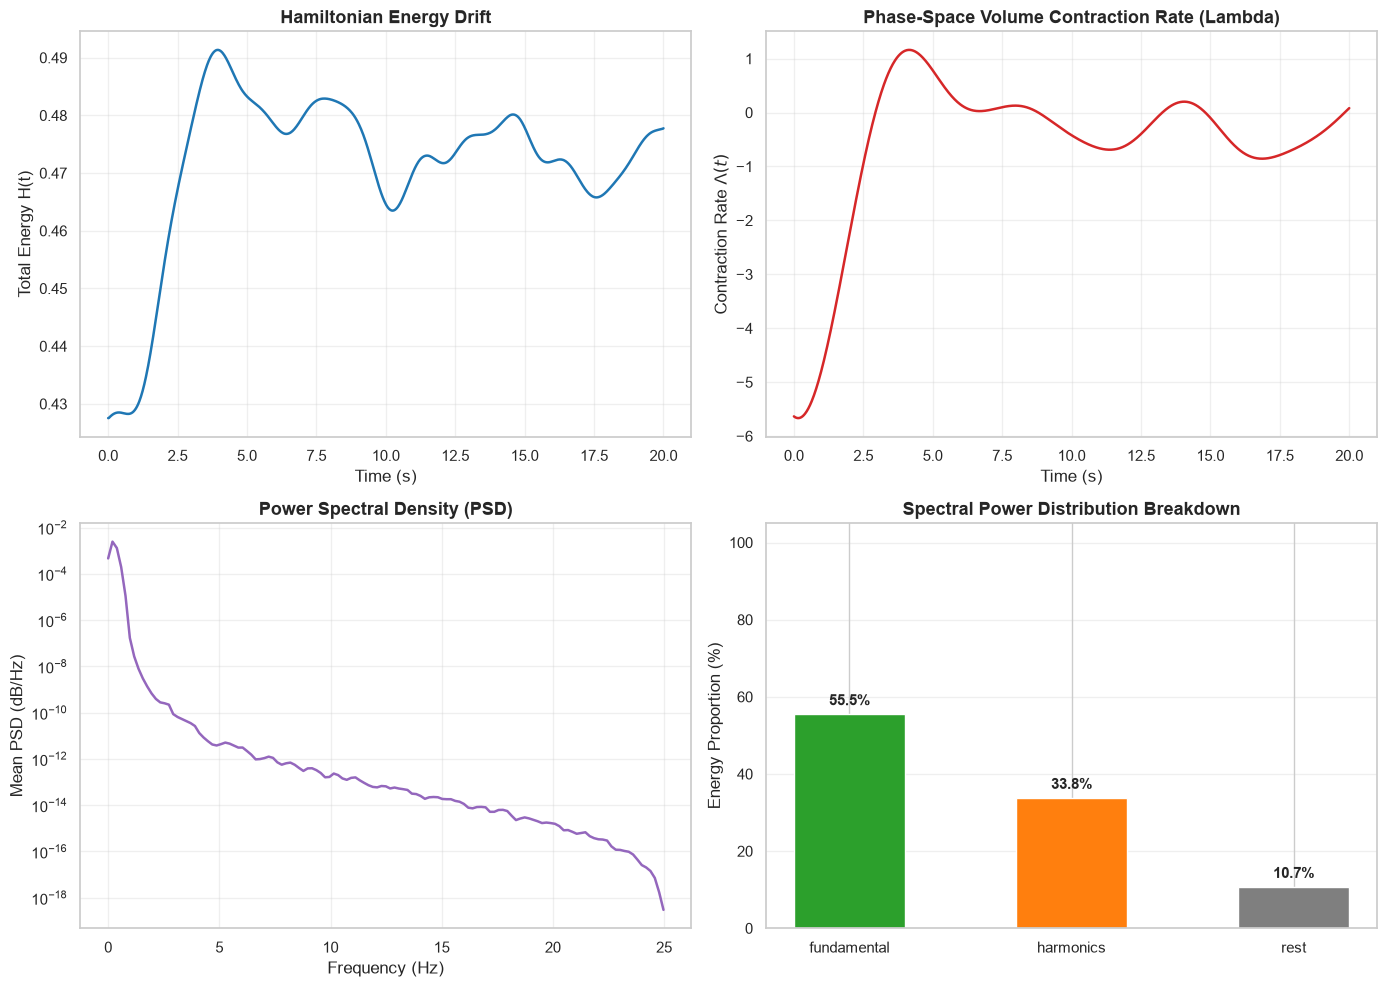

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Hamiltonian Energy Drift over time
axes[0, 0].plot(times, metrics.energy_trajectory, color="tab:blue", lw=1.8)
axes[0, 0].set_title("Hamiltonian Energy Drift", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Total Energy H(t)")
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Phase-Space Volume Contraction Rate (Lambda)
axes[0, 1].plot(times, metrics.lambda_trajectory, color="tab:red", lw=1.8)
axes[0, 1].set_title("Phase-Space Volume Contraction Rate (Lambda)", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel(r"Contraction Rate $\Lambda(t)$")
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Power Spectral Density (PSD)
axes[1, 0].semilogy(metrics.spectral_frequencies, metrics.spectral_psd_mean, color="tab:purple", lw=1.8)
axes[1, 0].set_title("Power Spectral Density (PSD)", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Frequency (Hz)")
axes[1, 0].set_ylabel("Mean PSD (dB/Hz)")
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Power distribution proportion
decomp = metrics.energy_decomposition
categories = list(decomp.keys())
proportions = [decomp[c] * 100.0 for c in categories]
colors = ["#2ca02c", "#ff7f0e", "#7f7f7f"]

bars = axes[1, 1].bar(categories, proportions, color=colors[: len(categories)], width=0.5)
axes[1, 1].set_title("Spectral Power Distribution Breakdown", fontsize=13, fontweight="bold")
axes[1, 1].set_ylabel("Energy Proportion (%)")
axes[1, 1].set_ylim(0, 105)
for bar in bars:
    h = bar.get_height()
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2.0,
        h + 1.5,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )
axes[1, 1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


## Graph Interpretation
1. **Hamiltonian Energy Drift** ($H(t)$ over time)
    - **What it measures:** The effective total energy $$H(t)=T_{\text{kinetic}}(t) + V_{\text{potential}}(t)$$ where:
        - $T=_{\text{kinetic}}(t) = \frac{1}{2N} \sum_{i} \Omega_i(t)^2$
        - $V_{\text{potential}}(t) = \frac{K}{N^2} \sum{i,j} A_{ij} \cos(\theta_i - \theta_j)$
    - **Physical Interpretation:**
        - The standard Kuramoto model is a dissipative gradient/phase-coupled system rather than a strictly conservative Hamiltonian system.
        - During the transient phase (as oscillators pull into phase clusters), kinetic and potential energies exchange dynamically.
2. **Phase-Space Volume Contraction Rate** ($\Lambda(t)$ over time)
3. **Power Spectral Density** (PSD of Velocities)
4. **Spectral Power Distribution Breakdown**